

| # | Model | Type | Financial Use Case |
|---|---|---|---|
| 1 | Random Forest | Regression | Insurance Premium Prediction |
| 2 | Naive Bayes | Binary Classification | Customer Churn Prediction |
| 3 | Logistic Regression | Binary Classification | Credit Card Approval Prediction |
| 4 | K-Nearest Neighbors (KNN) | Regression | Real Estate Property Valuation |



## 0. Imports & Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score, ConfusionMatrixDisplay
)

np.random.seed(42)
plt.rcParams["figure.dpi"] = 100
print("Libraries loaded successfully.")


Libraries loaded successfully.


## 1. Random Forest — Insurance Premium Prediction




In [ ]:
n = 1000
age          = np.random.uniform(18, 70, n)
bmi          = np.random.uniform(15, 45, n)
smoker       = np.random.binomial(1, 0.2, n)
prior_claims = np.random.poisson(1, n)
region_risk  = np.random.uniform(0, 1, n)

premium = (200 + 15*age + 25*bmi + 3000*smoker + 500*prior_claims
           + 800*region_risk + 600*np.sin(age/10) + np.random.randn(n)*150)
premium = np.clip(premium, 300, None)

df_rf = pd.DataFrame({
    "Age": age, "BMI": bmi, "Smoker": smoker,
    "Prior_Claims": prior_claims, "Region_Risk": region_risk, "Premium": premium
})
df_rf.head()


,Age,BMI,Smoker,Prior_Claims,Region_Risk,Premium
0,37.476086,20.553988,0,2,0.743905,2658.572169
1,67.437144,31.257028,0,1,0.919208,3532.700072
2,56.063685,41.188375,1,2,0.423770,5999.196798
3,49.130241,36.966747,0,1,0.342133,1960.401307
4,26.112969,39.196834,0,1,0.961551,3364.984273


### 1.4 Implementation

In [ ]:
X = df_rf[["Age", "BMI", "Smoker", "Prior_Claims", "Region_Risk"]]
y = df_rf["Premium"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=200, max_depth=7, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

r2 = r2_score(y_test, y_pred_rf)
mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("--- Random Forest: Insurance Premium Prediction ---")
print(f"R2 Score : {r2:.4f}")
print(f"MAE      : {mae:.2f}")
print(f"RMSE     : {rmse:.2f}")


--- Random Forest: Insurance Premium Prediction ---
R2 Score : 0.9655
MAE      : 200.96
RMSE     : 255.06


### 1.5 Evaluation & Interpretation

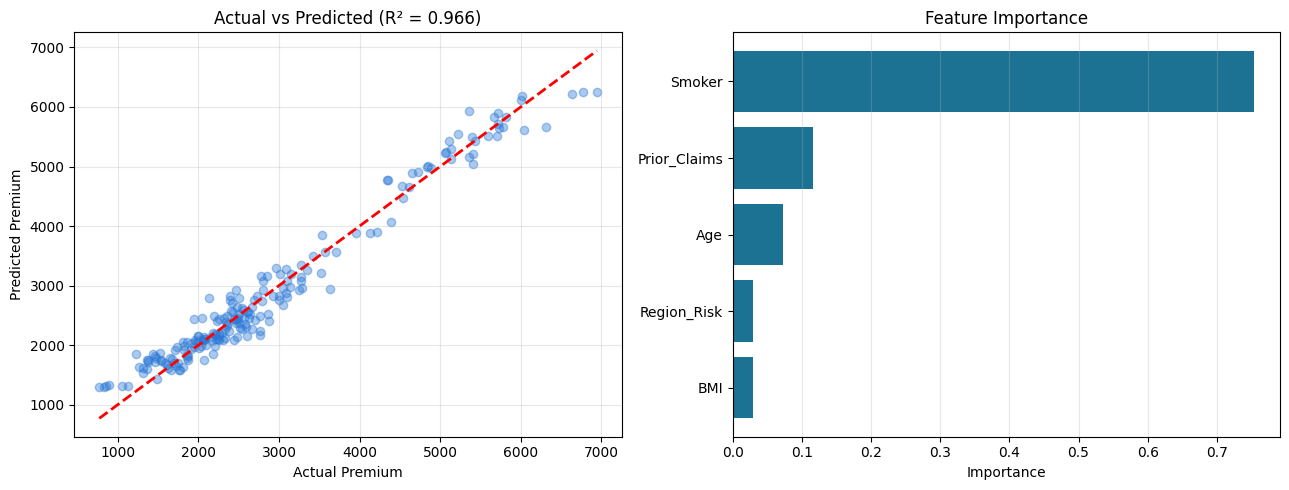

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred_rf, alpha=0.4, color="#2a78d6")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", linewidth=2)
axes[0].set_xlabel("Actual Premium")
axes[0].set_ylabel("Predicted Premium")
axes[0].set_title(f"Actual vs Predicted (R\u00b2 = {r2:.3f})")
axes[0].grid(alpha=0.3)

importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values()
axes[1].barh(importances.index, importances.values, color="#1C7293")
axes[1].set_title("Feature Importance")
axes[1].set_xlabel("Importance")
axes[1].grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.show()


---
## 2. Naive Bayes — Customer Churn Prediction




In [ ]:
n = 1000
tenure           = np.random.uniform(0, 72, n)
monthly_charges  = np.random.uniform(20, 150, n)
support_calls    = np.random.poisson(2, n)
contract_month   = np.random.binomial(1, 0.4, n)   # 1 = month-to-month contract (higher churn risk)
late_payments    = np.random.poisson(1, n)

churn_score = (-0.04*tenure + 0.015*monthly_charges + 0.5*support_calls
               + 1.2*contract_month + 0.4*late_payments + np.random.randn(n)*0.7 - 1)
prob_churn = 1 / (1 + np.exp(-churn_score))
churn = (prob_churn > np.random.uniform(0, 1, n)).astype(int)

df_nb = pd.DataFrame({
    "Tenure": tenure, "Monthly_Charges": monthly_charges, "Support_Calls": support_calls,
    "Contract_Month_to_Month": contract_month, "Late_Payments": late_payments, "Churn": churn
})
print("Churn rate in dataset:", round(df_nb["Churn"].mean(), 3))
df_nb.head()


Churn rate in dataset: 0.62


,Tenure,Monthly_Charges,Support_Calls,Contract_Month_to_Month,Late_Payments,Churn
0,9.437750,108.049515,5,0,0,1
1,55.163311,57.645752,3,0,2,0
2,67.135966,95.035967,6,0,2,1
3,68.206097,28.565981,1,0,1,0
4,26.569277,44.867590,4,0,0,1


### 2.4 Implementation

In [ ]:
X = df_nb.drop(columns=["Churn"])
y = df_nb["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)
y_prob_nb = nb_model.predict_proba(X_test)[:, 1]

print("--- Naive Bayes: Customer Churn Prediction ---")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_nb):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_nb):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_nb):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob_nb):.4f}")


--- Naive Bayes: Customer Churn Prediction ---
Accuracy  : 0.7350
Precision : 0.7591
Recall    : 0.8387
F1 Score  : 0.7969
ROC-AUC   : 0.8129


### 2.5 Evaluation & Interpretation

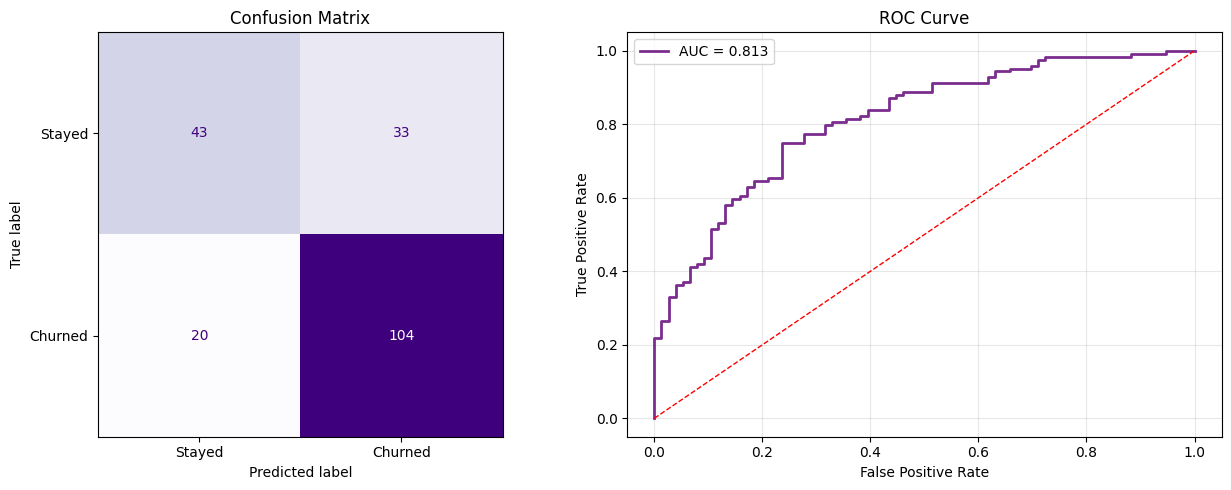

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred_nb)
ConfusionMatrixDisplay(cm, display_labels=["Stayed", "Churned"]).plot(ax=axes[0], cmap="Purples", colorbar=False)
axes[0].set_title("Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test, y_prob_nb)
axes[1].plot(fpr, tpr, color="#7B2D8E", lw=2, label=f"AUC = {roc_auc_score(y_test, y_prob_nb):.3f}")
axes[1].plot([0, 1], [0, 1], "r--", lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


---
## 3. Logistic Regression — Credit Card Approval Prediction




In [ ]:
n = 1000
income          = np.random.uniform(15000, 150000, n)
credit_score    = np.random.uniform(300, 850, n)
debt_ratio      = np.random.uniform(0, 1, n)
emp_years       = np.random.uniform(0, 25, n)
existing_cards  = np.random.randint(0, 6, n)

approval_score = (0.00003*income + 0.008*credit_score - 3.5*debt_ratio
                   + 0.1*emp_years - 0.3*existing_cards + np.random.randn(n)*0.8 - 3)
prob_approve = 1 / (1 + np.exp(-approval_score))
approved = (prob_approve > np.random.uniform(0, 1, n)).astype(int)

df_log = pd.DataFrame({
    "Income": income, "Credit_Score": credit_score, "Debt_Ratio": debt_ratio,
    "Employment_Years": emp_years, "Existing_Cards": existing_cards, "Approved": approved
})
print("Approval rate in dataset:", round(df_log["Approved"].mean(), 3))
df_log.head()


Approval rate in dataset: 0.843


,Income,Credit_Score,Debt_Ratio,Employment_Years,Existing_Cards,Approved
0,55708.441794,554.132891,0.279571,7.950160,4,1
1,76300.279482,401.693567,0.971847,8.471074,3,1
2,86029.272558,468.155611,0.178776,18.790122,1,1
3,129818.391591,725.678440,0.511214,19.624904,4,1
4,140767.011845,549.561925,0.239652,5.741117,0,1


### 3.4 Implementation

In [ ]:
X = df_log.drop(columns=["Approved"])
y = df_log["Approved"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

log_model = LogisticRegression()
log_model.fit(X_train_s, y_train)
y_pred_log = log_model.predict(X_test_s)
y_prob_log = log_model.predict_proba(X_test_s)[:, 1]

print("--- Logistic Regression: Credit Card Approval Prediction ---")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_log):.4f}")
print(f"Precision : {precision_score(y_test, y_pred_log):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred_log):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred_log):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob_log):.4f}")


--- Logistic Regression: Credit Card Approval Prediction ---
Accuracy  : 0.8650
Precision : 0.8989
Recall    : 0.9467
F1 Score  : 0.9222
ROC-AUC   : 0.8601


### 3.5 Evaluation & Interpretation

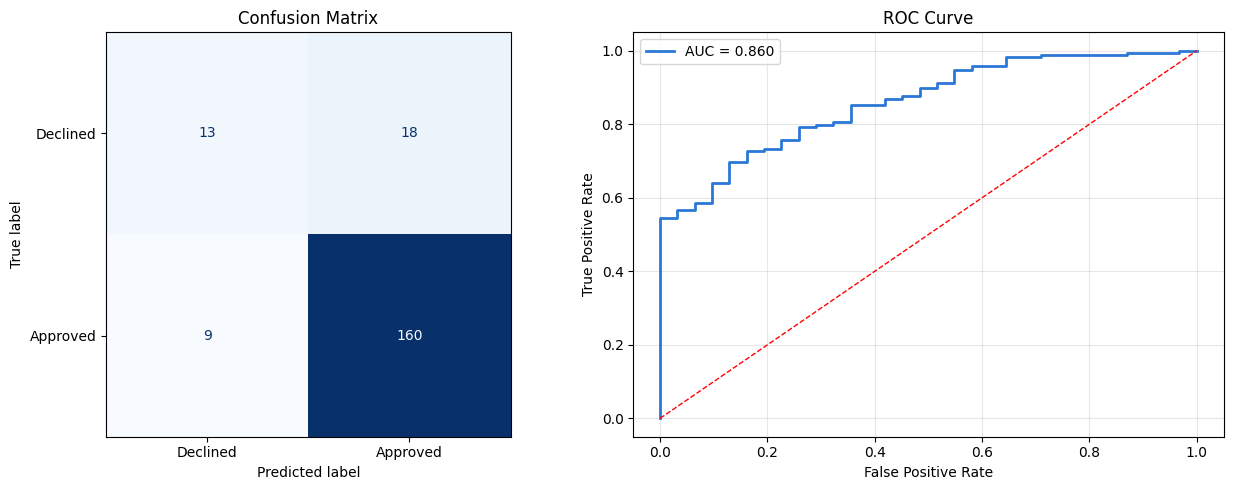

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred_log)
ConfusionMatrixDisplay(cm, display_labels=["Declined", "Approved"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion Matrix")

fpr, tpr, _ = roc_curve(y_test, y_prob_log)
axes[1].plot(fpr, tpr, color="#2a78d6", lw=2, label=f"AUC = {roc_auc_score(y_test, y_prob_log):.3f}")
axes[1].plot([0, 1], [0, 1], "r--", lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


---
## 4. K-Nearest Neighbors (KNN) — Real Estate Property Valuation




In [ ]:
n = 1000
sqft            = np.random.uniform(500, 4000, n)
bedrooms        = np.random.randint(1, 6, n)
location_score  = np.random.uniform(1, 10, n)
age_property    = np.random.uniform(0, 50, n)
amenities       = np.random.uniform(0, 10, n)

value = (50000 + 120*sqft + 8000*bedrooms + 15000*location_score
          - 800*age_property + 4000*amenities + np.random.randn(n)*20000)
value = np.clip(value, 30000, None)

df_knn = pd.DataFrame({
    "Sqft": sqft, "Bedrooms": bedrooms, "Location_Score": location_score,
    "Age_of_Property": age_property, "Amenities": amenities, "Property_Value": value
})
df_knn.head()


,Sqft,Bedrooms,Location_Score,Age_of_Property,Amenities,Property_Value
0,3037.987909,3,4.533136,24.976770,0.619999,459840.950657
1,1246.214990,3,6.967918,31.224328,3.987493,316522.732028
2,2652.826781,2,7.486158,6.900730,3.025238,499625.356737
3,2066.412685,3,3.672256,2.176104,2.403598,368414.589479
4,1055.293095,2,1.869593,0.672998,6.045346,254952.931588


### 4.4 Implementation

In [ ]:
X = df_knn[["Sqft", "Bedrooms", "Location_Score", "Age_of_Property", "Amenities"]]
y = df_knn["Property_Value"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

knn_model = KNeighborsRegressor(n_neighbors=7)
knn_model.fit(X_train_s, y_train)
y_pred_knn = knn_model.predict(X_test_s)

r2 = r2_score(y_test, y_pred_knn)
mae = mean_absolute_error(y_test, y_pred_knn)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_knn))

print("--- KNN: Real Estate Property Valuation ---")
print(f"R2 Score : {r2:.4f}")
print(f"MAE      : {mae:.2f}")
print(f"RMSE     : {rmse:.2f}")


--- KNN: Real Estate Property Valuation ---
R2 Score : 0.9400
MAE      : 25943.65
RMSE     : 32915.44


### 4.5 Evaluation & Interpretation

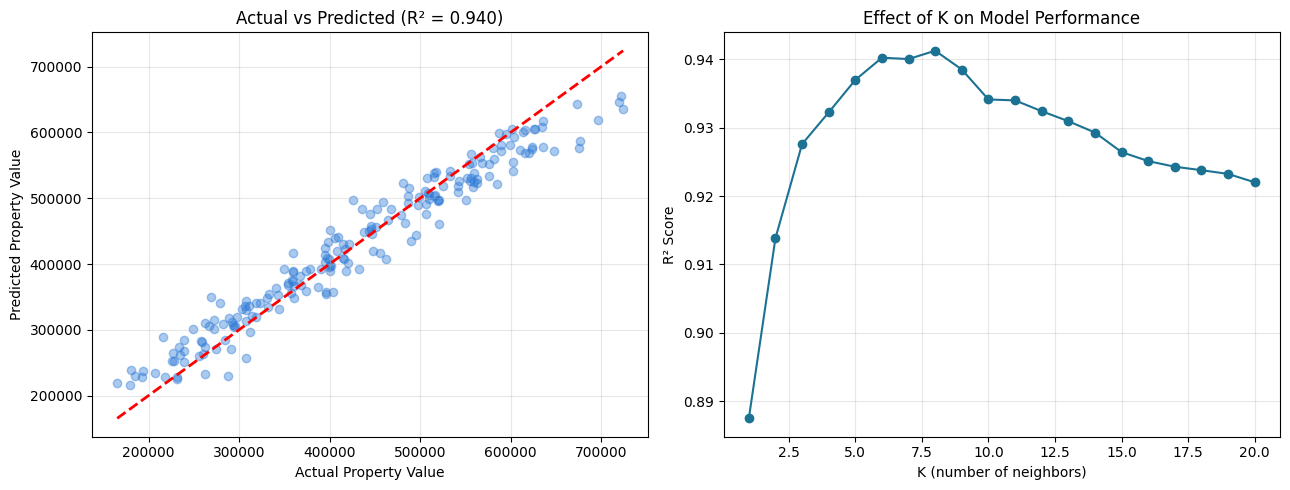

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred_knn, alpha=0.4, color="#2a78d6")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", linewidth=2)
axes[0].set_xlabel("Actual Property Value")
axes[0].set_ylabel("Predicted Property Value")
axes[0].set_title(f"Actual vs Predicted (R\u00b2 = {r2:.3f})")
axes[0].grid(alpha=0.3)

# Effect of K on performance
k_values = range(1, 21)
r2_scores = []
for k in k_values:
    model_k = KNeighborsRegressor(n_neighbors=k)
    model_k.fit(X_train_s, y_train)
    r2_scores.append(r2_score(y_test, model_k.predict(X_test_s)))

axes[1].plot(list(k_values), r2_scores, marker="o", color="#1C7293")
axes[1].set_xlabel("K (number of neighbors)")
axes[1].set_ylabel("R\u00b2 Score")
axes[1].set_title("Effect of K on Model Performance")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
